# COGS 45 — Lab Homework #4: Abstract Rule Learning

## Setup

Clone the repository and install dependencies.


In [1]:
! git clone https://github.com/sfrankland/emergent_symbols.git
!pip install colorlog -q


Cloning into 'emergent_symbols'...
remote: Enumerating objects: 355, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 355 (delta 35), reused 37 (delta 18), pack-reused 299 (from 1)
Receiving objects: 100% (355/355), 108.55 KiB | 2.01 MiB/s, done.
Resolving deltas: 100% (157/157), done.


In [2]:
%cd emergent_symbols/


/content/emergent_symbols


---
## 1. Train Three Models on the Identity Rules Task

Train each model on the identity rules task with **m_holdout = 95** (train on only 5 objects, test on 95 held-out objects). This is the most extreme generalization regime — the models must learn an abstract rule from minimal experience.

**Important:** Make sure `--test_gen_method subsample` is included or training will take a very long time.

Run the cell below for the **ESBN**, then change `--model_name` to **LSTM** and **NTM** and run it two more times.


In [11]:
# Run this cell THREE times, changing --model_name each time:
#   1st run: ESBN
#   2nd run: LSTM
#   3rd run: NTM

! python3 ./train_and_eval.py     --model_name NTM     --task identity_rules     --m_holdout 75     --epochs 5     --encoder 'conv'     --norm_type contextnorm     --lr 5e-4     --run 1     --device 0     --test_gen_method subsample


[2026-05-08 19:34:54,027] Generating task: identity_rules...
[2026-05-08 19:34:54,027] n_shapes = 100...
[2026-05-08 19:34:54,027] m_holdout = 75...
[2026-05-08 19:34:54,028] Total possible training trials = 18216000...
[2026-05-08 19:34:54,028] Training set size = 10000...
[2026-05-08 19:34:54,028] Total possible test trials = 1750248000...
[2026-05-08 19:34:54,028] Test set size = 10000...
[2026-05-08 19:38:41,241] Building encoder...
[2026-05-08 19:38:41,241] Building convolutional encoder...
[2026-05-08 19:38:41,242] Conv layers...
[2026-05-08 19:38:41,243] FC layers...
[2026-05-08 19:38:41,247] Building LSTM and output layers...
[2026-05-08 19:38:41,265] Initialize memory matrix as learnable parameter...
[2026-05-08 19:38:41,284] Setting up optimizer...
[2026-05-08 19:38:46,046] Training begins...
[2026-05-08 19:38:46,579] [Epoch: 1] [Batch: 0 of 313] [Loss = 1.3577] [Accuracy = 34.38] [0.530 sec/batch]
[2026-05-08 19:38:51,993] [Epoch: 1] [Batch: 10 of 313] [Loss = 1.4809] [Accur

---
## 1a. Plot Training Loss Over Time

Load the training progress files for all three models and plot their loss curves on the same graph (as in Figure 4c of Webb et al.).

The results files have three columns:
- Column 0: training batch index within each epoch
- Column 1: training loss (cross-entropy)
- Column 2: training accuracy (multiple-choice performance)


In [12]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import genfromtxt

plt.rcParams['figure.dpi'] = 150


In [13]:
def load_training_data(model_name, task, m, max_epochs=5, lr='0.0005'):
    """Load and concatenate training progress across epochs for a given model."""
    all_data = []
    for j in range(max_epochs):
        fname = f'./train_prog/{task}/m{m}/{model_name}_contextnorm_lr{lr}/epoch_{j+1}.txt'
        print(f'  Reading {model_name} epoch {j+1}')
        this_epoch = genfromtxt(fname, delimiter=',', skip_header=1, usecols=(0, 1, 2))
        this_epoch = np.atleast_2d(this_epoch)  # ensure 2D even if only one row
        all_data.append(this_epoch)
    return np.concatenate(all_data, axis=0)

# Load all three models
print("Loading ESBN...")
ESBN_train = load_training_data('ESBN', 'identity_rules', 95)
print("Loading LSTM...")
LSTM_train = load_training_data('LSTM', 'identity_rules', 95)
print("Loading NTM...")
NTM_train = load_training_data('NTM', 'identity_rules', 95)


Loading ESBN...
  Reading ESBN epoch 1


FileNotFoundError: ./train_prog/identity_rules/m95/ESBN_contextnorm_lr0.0005/epoch_1.txt not found.

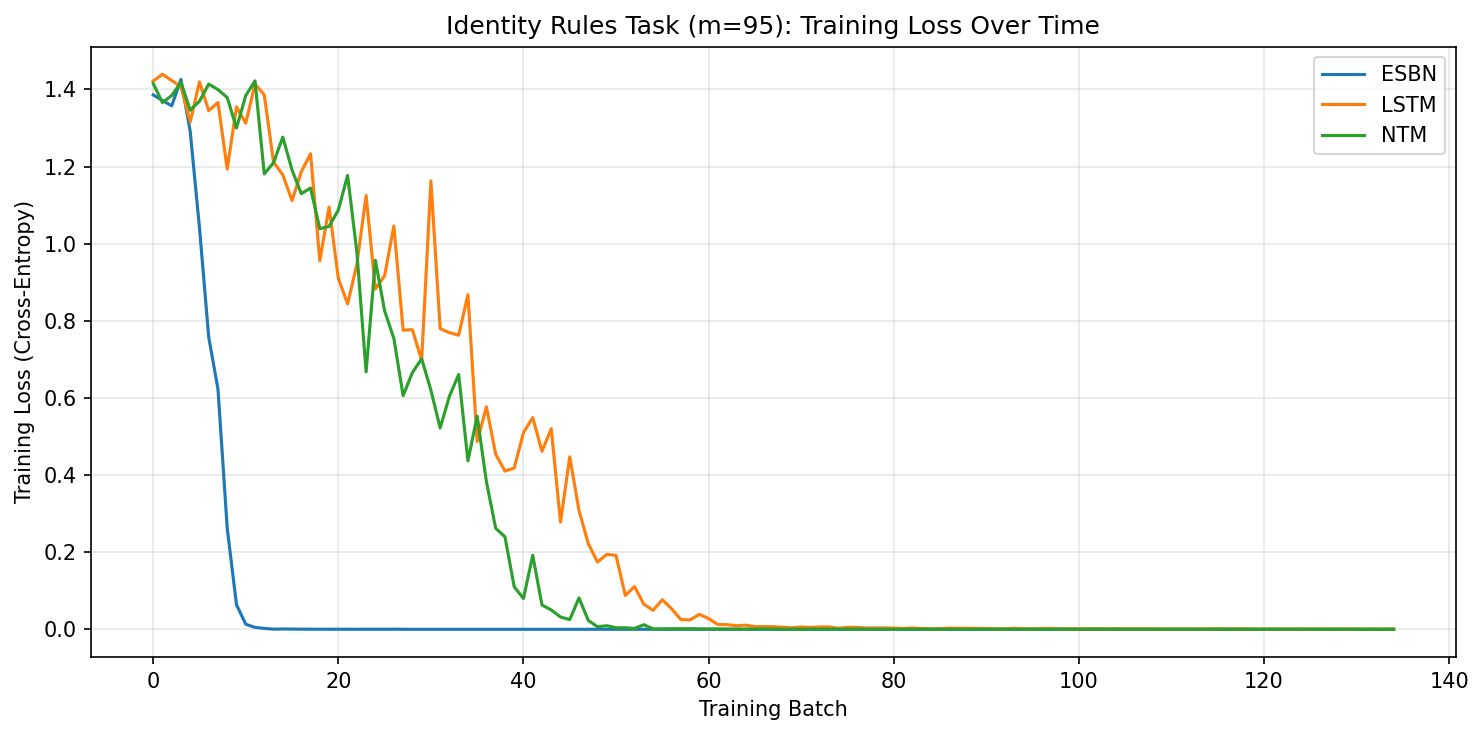

In [ ]:
# Plot training loss (column 1) for all three models
plt.figure(figsize=(10, 5))
plt.plot(ESBN_train[:, 1], label='ESBN', linewidth=1.5)
plt.plot(LSTM_train[:, 1], label='LSTM', linewidth=1.5)
plt.plot(NTM_train[:, 1], label='NTM', linewidth=1.5)

plt.xlabel('Training Batch')
plt.ylabel('Training Loss (Cross-Entropy)')
plt.title('Identity Rules Task (m=95): Training Loss Over Time')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Question 1a:** Do the three models require the same amount of experience to achieve a given level of training loss? Which model converges fastest? What does this tell you about the role of architectural inductive biases in learning speed?


---
## 1b. Plot Test Accuracy on Held-Out Objects

Now load the test results — how well does each model generalize its learned rule to the 95 objects it *never saw during training*?


In [ ]:
# Load test results for each model
def load_test_data(model_name, task, m, lr='0.0005', run=1):
    """Load test accuracy for a given model."""
    fname = f'./test/{task}/m{m}/{model_name}_contextnorm_lr{lr}/run{run}.txt'
    data = genfromtxt(fname, delimiter=',', skip_header=1, usecols=(0, 1))
    data = np.atleast_2d(data)
    return data

ESBN_test = load_test_data('ESBN', 'identity_rules', 95)
LSTM_test = load_test_data('LSTM', 'identity_rules', 95)
NTM_test = load_test_data('NTM', 'identity_rules', 95)

# Column 1 is accuracy
esbn_acc = ESBN_test[-1, 1] if ESBN_test.ndim > 1 else ESBN_test[1]
lstm_acc = LSTM_test[-1, 1] if LSTM_test.ndim > 1 else LSTM_test[1]
ntm_acc = NTM_test[-1, 1] if NTM_test.ndim > 1 else NTM_test[1]

print(f"Test Accuracy (held-out objects):")
print(f"  ESBN: {esbn_acc:.3f}")
print(f"  LSTM: {lstm_acc:.3f}")
print(f"  NTM:  {ntm_acc:.3f}")


Test Accuracy (held-out objects):
  ESBN: 100.000
  LSTM: 72.470
  NTM:  55.440


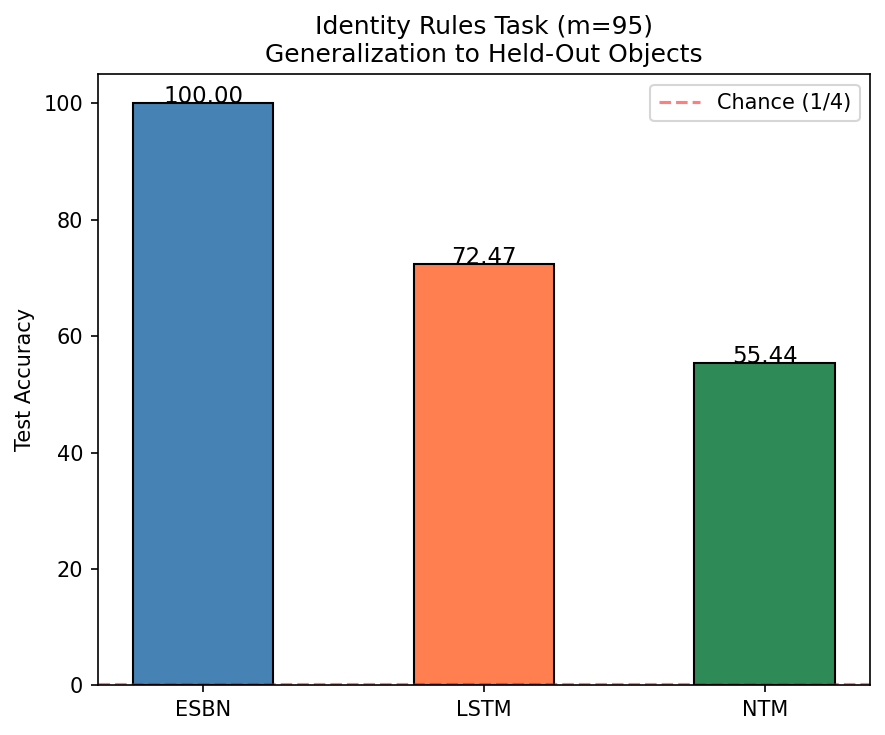

In [ ]:
# Bar graph of test accuracy
plt.figure(figsize=(6, 5))
models = ['ESBN', 'LSTM', 'NTM']
accuracies = [esbn_acc, lstm_acc, ntm_acc]
colors = ['steelblue', 'coral', 'seagreen']

bars = plt.bar(models, accuracies, color=colors, edgecolor='black', width=0.5)
plt.ylabel('Test Accuracy')
plt.title('Identity Rules Task (m=95)\nGeneralization to Held-Out Objects')
plt.ylim(0, 105)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.2f}', ha='center', fontsize=11)

# Add chance line
plt.axhline(y=0.25, color='red', linestyle='--', alpha=0.5, label='Chance (1/4)')
plt.legend()
plt.tight_layout()
plt.show()


**Question 1b:** How well does each model generalize the learned rule to new objects? Which model(s) can transfer the identity rule to objects never seen during training? Which model(s) fail?

---
## Written Questions

**Question 2.** Marcus et al. claim that statistical learning mechanisms alone (like those in the RNN we used to predict Shakespeare text) are insufficient to explain the abstract rule-learning competency exhibited by 7-month-old infants. Do your results suggest that augmenting those statistical learning mechanisms with an external memory enables the model to learn abstract rules capable of generalizing to novel inputs? Can *any* external memory system achieve this? If not, what specific architectural feature seems to be required?

**Question 3.** Philosophers have long debated what aspects of the mind are innate and what is learned via experience. Those who emphasize innate knowledge are often called *rationalists*; those who emphasize learning from experience are called *empiricists*. How does your experiment bear on that debate? Consider: the ESBN achieves infant-like generalization, but only because its architecture was designed with a specific inductive bias (separating roles from fillers). Is this inductive bias more like "innate knowledge" or "innate architecture"? Is there a meaningful difference?
